# TECHNICAL DATA ( DATA PREPROCESSING )

IMPORT ALL THE LIBRARIES

In [55]:
import os
import glob
import json
import re
import string
import random
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


LOAD THE STOCK PRICE DATA

In [2]:
# Path to price folder
price_path = "price/raw"

# Get all csv files
price_files = glob.glob(os.path.join(price_path, "*.csv"))

all_prices = []

for file in price_files:
    df = pd.read_csv(file)
    
    # Extract ticker name from filename
    ticker = os.path.basename(file).replace(".csv", "")
    df['Ticker'] = ticker
    
    all_prices.append(df)

price_df = pd.concat(all_prices, ignore_index=True)

print(price_df.head())


         Date       Open       High        Low      Close  Adj Close  \
0  2012-09-04  95.108574  96.448570  94.928574  96.424286  87.121140   
1  2012-09-05  96.510002  96.621429  95.657143  95.747147  86.509338   
2  2012-09-06  96.167145  96.898575  95.828575  96.610001  87.288956   
3  2012-09-07  96.864288  97.497147  96.538574  97.205711  87.827171   
4  2012-09-10  97.207146  97.612854  94.585716  94.677139  85.542564   

        Volume Ticker  
0   91973000.0   AAPL  
1   84093800.0   AAPL  
2   97799100.0   AAPL  
3   82416600.0   AAPL  
4  121999500.0   AAPL  


CLEAN AND STANDARDIZE COLUMNS

In [3]:
price_df.columns = [col.lower() for col in price_df.columns]
print(price_df.columns)

Index(['date', 'open', 'high', 'low', 'close', 'adj close', 'volume',
       'ticker'],
      dtype='str')


In [4]:
# Proper date formatting and sorting
price_df['date'] = pd.to_datetime(price_df['date'])
price_df = price_df.sort_values(['ticker', 'date'])

DATA CLEANING

In [5]:
# check missing values
print(price_df.isnull().sum())

date         0
open         3
high         3
low          3
close        3
adj close    3
volume       3
ticker       0
dtype: int64


In [6]:
# Drop rows with missing values (if any)
price_df = price_df.dropna()

In [7]:
print(price_df.describe())

                             date           open           high  \
count                      108589  108589.000000  108589.000000   
mean   2015-03-13 23:02:06.941034    2414.480741    2426.328572   
min           2012-09-04 00:00:00       2.130000       2.280000   
25%           2013-12-12 00:00:00      40.349998      40.639999   
50%           2015-03-19 00:00:00      65.949997      66.480003   
75%           2016-06-14 00:00:00      97.690002      98.470001   
max           2017-09-01 00:00:00  272800.000000  272885.000000   
std                           NaN   21741.872688   21844.336892   

                 low          close      adj close        volume  
count  108589.000000  108589.000000  108589.000000  1.085890e+05  
mean     2400.854887    2414.218533    2409.914671  9.060307e+06  
min         1.960000       2.020000       2.020000  0.000000e+00  
25%        40.090000      40.369999      36.490002  1.197100e+06  
50%        65.449997      65.988457      60.509998  3.549500e

CREATE TARGET VARIABLE

In [8]:
def engineer_price_features(price_df: pd.DataFrame) -> pd.DataFrame:
    df = price_df.copy()

    df["return"]        = df.groupby("ticker")["close"].pct_change()
    df["target_return"] = df.groupby("ticker")["return"].shift(-1)

    df["target"] = np.where(
        df["target_return"].notna(),
        (df["target_return"] > 0).astype(int),
        np.nan,
    )

    df["ma5"]          = df.groupby("ticker")["close"].transform(lambda s: s.rolling(5).mean())
    df["ma10"]         = df.groupby("ticker")["close"].transform(lambda s: s.rolling(10).mean())
    df["volatility_5"] = df.groupby("ticker")["close"].transform(lambda s: s.rolling(5).std())
    df["momentum_5"]   = df.groupby("ticker")["close"].transform(lambda s: s - s.shift(5))
    df["volume_change"]= df.groupby("ticker")["volume"].pct_change()
    df["lag1"]         = df.groupby("ticker")["close"].shift(1)
    df["lag2"]         = df.groupby("ticker")["close"].shift(2)

    df = df.dropna(subset=["target"]).copy()

    threshold = 0.002
    df["target"] = np.where(
        df["target_return"] > threshold, 1,
        np.where(df["target_return"] < -threshold, 0, np.nan)
    )

    # drop the neutral zone NaNs introduced by the second overwrite
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)

    return df

REQUIRED STATISTICS FOR REPORT

In [9]:
# Number of unique stocks
num_stocks = price_df['ticker'].nunique()
print("Number of stocks:", num_stocks)

Number of stocks: 88


In [10]:
# Number of days
num_days = price_df['date'].nunique()
print("Number of unique trading days:", num_days)

Number of unique trading days: 1258


In [11]:
# Class distribution
price_df = engineer_price_features(price_df)
print(price_df['target'].value_counts(normalize=True))

target
1    0.523629
0    0.476371
Name: proportion, dtype: float64


In [12]:
print(price_df.columns)

Index(['date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'ticker',
       'return', 'target_return', 'target', 'ma5', 'ma10', 'volatility_5',
       'momentum_5', 'volume_change', 'lag1', 'lag2'],
      dtype='str')


# FUNDAMENTAL DATA ( DATA PREPROCESSING )

EXTRACT TWEET DATA 

In [13]:
TWEET_BASE_DIR = "tweet/raw"

def load_stocknet_tweets(base_dir: str) -> pd.DataFrame:
    ticker_paths = [p for p in glob.glob(os.path.join(base_dir, "*")) if os.path.isdir(p)]
    all_rows = []

    for ticker_path in tqdm(ticker_paths, desc="Loading tickers"):
        ticker = os.path.basename(ticker_path).upper().strip()
        day_files = glob.glob(os.path.join(ticker_path, "*"))

        for file in day_files:
            date_str = os.path.basename(file)  # often '2014-01-02' (no extension)

            with open(file, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    tw = json.loads(line)

                    all_rows.append({
                        "ticker": ticker,
                        "date": date_str,
                        "text": tw.get("text", ""),
                        "retweet_count": tw.get("retweet_count", 0),
                        "favorite_count": tw.get("favorite_count", 0),
                        })

    tweets_df = pd.DataFrame(all_rows)
    if tweets_df.empty:
        raise ValueError("No tweets were loaded. Check tweet/raw path and file format.")

    tweets_df["date"] = pd.to_datetime(tweets_df["date"], errors="coerce").dt.normalize()
    tweets_df["ticker"] = tweets_df["ticker"].astype(str).str.upper().str.strip()
    tweets_df["retweet_count"] = pd.to_numeric(tweets_df["retweet_count"], errors="coerce").fillna(0).astype(int)
    tweets_df["favorite_count"] = pd.to_numeric(tweets_df["favorite_count"], errors="coerce").fillna(0).astype(int)
    return tweets_df

tweets_df = load_stocknet_tweets(TWEET_BASE_DIR)

print("Total tweets:", len(tweets_df))
print("Tickers with tweets:", tweets_df["ticker"].nunique())

Loading tickers: 100%|██████████| 87/87 [19:32<00:00, 13.48s/it]


Total tweets: 119844
Tickers with tweets: 87


In [14]:
display(tweets_df.head(5))

,ticker,date,text,retweet_count,favorite_count
0,AAPL,2014-01-01,RT @philstockworld: Summary of Yesterday's Web...,0,0
1,AAPL,2014-01-01,RT @philstockworld: Summary of Yesterday's Web...,0,0
2,AAPL,2014-01-01,iTV Will Boost Apple http://t.co/8dup4cQc08 $A...,0,0
3,AAPL,2014-01-01,#iPhone users are more intelligent than #Samsu...,0,0
4,AAPL,2014-01-01,RT @philstockworld: Summary of Yesterday's Web...,0,0


In [15]:
print("\nData types and non-null counts:")
print(tweets_df.info())


Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 119844 entries, 0 to 119843
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ticker          119844 non-null  str           
 1   date            119844 non-null  datetime64[us]
 2   text            119844 non-null  str           
 3   retweet_count   119844 non-null  int64         
 4   favorite_count  119844 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 17.4 MB
None


DATA CLEANING 

In [16]:
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text: str) -> str:
    text = "" if text is None else str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\$[a-z]+", " ", text)
    text = re.sub(r"[\(\[]\s*[A-Z]{1,5}\s*[\)\]]", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = [w for w in text.split() if w.isalpha() and w not in stop_words and len(w) > 2]
    return " ".join(tokens)

tweets_df["clean_text"] = tweets_df["text"].apply(clean_text)

# Proper date formatting and sorting
tweets_df['date'] = pd.to_datetime(tweets_df['date'])
tweets_df = tweets_df.sort_values(['ticker', 'date'])

# drop rows that became empty after cleaning
tweets_df = tweets_df[tweets_df["clean_text"].str.strip().ne("")]
tweets_df = tweets_df.drop_duplicates(subset=["ticker", "date", "text"]).reset_index(drop=True)

display(tweets_df.head())

,ticker,date,text,retweet_count,favorite_count,clean_text
0,AAPL,2014-01-01,RT @philstockworld: Summary of Yesterday's Web...,0,0,summary yesterdays webcast featuring traderedu...
1,AAPL,2014-01-01,iTV Will Boost Apple http://t.co/8dup4cQc08 $A...,0,0,itv boost apple apple
2,AAPL,2014-01-01,#iPhone users are more intelligent than #Samsu...,0,0,iphone users intelligent samsung blackberry ht...
3,AAPL,2014-01-01,2013 Wrap-Up And Trading Set Review - Part III...,0,0,wrapup trading set review apple
4,AAPL,2014-01-01,Apple Screwed Up Big Time http://t.co/Q2Pzk2VO...,0,0,apple screwed big time


FEATURE EXTRACTION

In [17]:
def basic_tweet_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["clean_text"] = out["text"].apply(clean_text)
    out = out[out["clean_text"].str.strip().ne("")].copy()
    out = out.drop_duplicates(subset=["ticker", "date", "text"]).reset_index(drop=True)

    out["engagement"] = out["retweet_count"] + out["favorite_count"]
    out["word_count"] = out["clean_text"].str.split().apply(len)
    out["char_count"] = out["clean_text"].str.len()
    out["unique_word_count"] = out["clean_text"].str.split().apply(lambda x: len(set(x)) if isinstance(x, list) else 0)
    out["lexical_diversity"] = np.where(out["word_count"] > 0, out["unique_word_count"] / out["word_count"], 0.0)
    out["has_question"] = out["text"].astype(str).str.contains(r"\?", regex=True).astype(int)
    out["has_exclaim"] = out["text"].astype(str).str.contains("!", regex=False).astype(int)
    return out

tweets_df = basic_tweet_features(tweets_df)

print("Tweets shape:", tweets_df.shape)
display(tweets_df.head())

Tweets shape: (103898, 13)


,ticker,date,text,retweet_count,favorite_count,clean_text,engagement,word_count,char_count,unique_word_count,lexical_diversity,has_question,has_exclaim
0,AAPL,2014-01-01,RT @philstockworld: Summary of Yesterday's Web...,0,0,summary yesterdays webcast featuring traderedu...,0,7,78,7,1.00,0,0
1,AAPL,2014-01-01,iTV Will Boost Apple http://t.co/8dup4cQc08 $A...,0,0,itv boost apple apple,0,4,21,3,0.75,0,0
2,AAPL,2014-01-01,#iPhone users are more intelligent than #Samsu...,0,0,iphone users intelligent samsung blackberry ht...,0,7,54,7,1.00,0,0
3,AAPL,2014-01-01,2013 Wrap-Up And Trading Set Review - Part III...,0,0,wrapup trading set review apple,0,5,31,5,1.00,0,0
4,AAPL,2014-01-01,Apple Screwed Up Big Time http://t.co/Q2Pzk2VO...,0,0,apple screwed big time,0,4,22,4,1.00,0,0


In [18]:

tickers_with_tweets = tweets_df["ticker"].astype(str).str.upper().str.strip().nunique()
total_tweets = len(tweets_df)

print("Total tweets:", total_tweets)
print("Tickers with tweets:", tickers_with_tweets)


per_ticker = (tweets_df.groupby("ticker")
                .agg(tweet_count=("text","size"))
                .sort_values("tweet_count", ascending=False))
print(per_ticker.head(10))


Total tweets: 103898
Tickers with tweets: 87
        tweet_count
ticker             
AAPL          17615
FB             9650
GOOG           5941
AMZN           5365
T              5017
MSFT           3252
D              2979
BABA           2930
PCLN           2436
BAC            2322


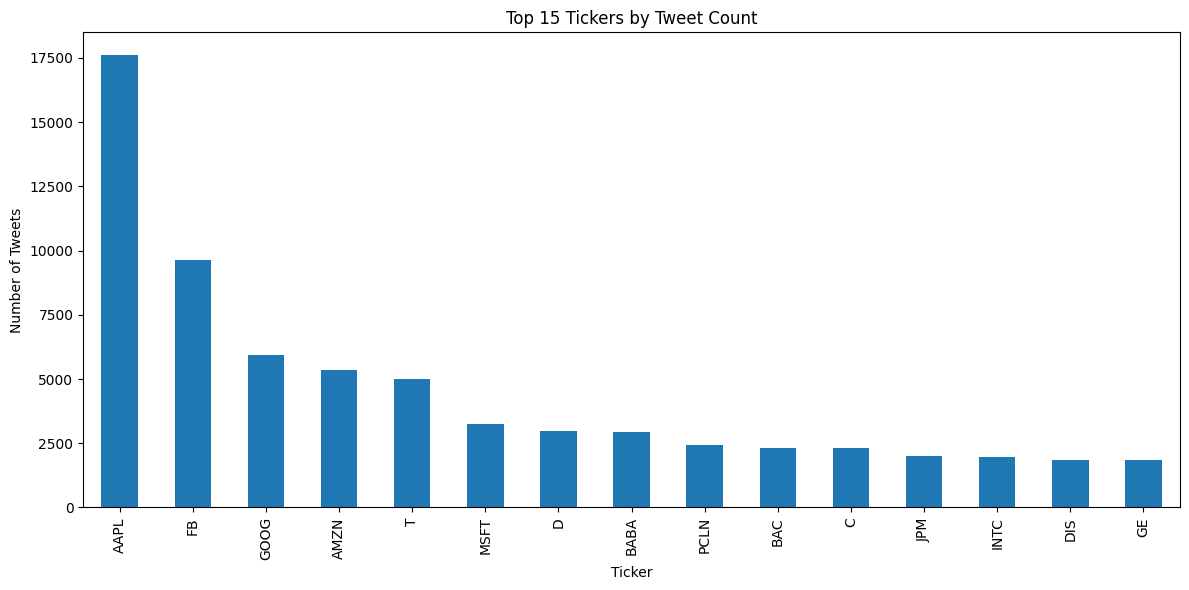

In [51]:
per_ticker = (
    tweets_df.groupby("ticker")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
per_ticker.plot(kind="bar")
plt.title("Top 15 Tickers by Tweet Count")
plt.xlabel("Ticker")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

In [19]:
from collections import Counter
counter = Counter(" ".join(tweets_df["clean_text"]).split())
display("Top 25 tokens:", counter.most_common(25))

'Top 25 tokens:'

[('stocks', 12814),
 ('stock', 11148),
 ('apple', 6421),
 ('amp', 3963),
 ('new', 3955),
 ('nasdaq', 3431),
 ('market', 3375),
 ('news', 3372),
 ('trading', 3286),
 ('earnings', 3152),
 ('investing', 3117),
 ('buy', 2921),
 ('share', 2438),
 ('facebook', 2403),
 ('like', 2358),
 ('today', 2340),
 ('stockmarket', 2322),
 ('corp', 2225),
 ('pennystocks', 2188),
 ('research', 2178),
 ('watch', 2174),
 ('invest', 2174),
 ('google', 2141),
 ('price', 2137),
 ('updated', 2118)]

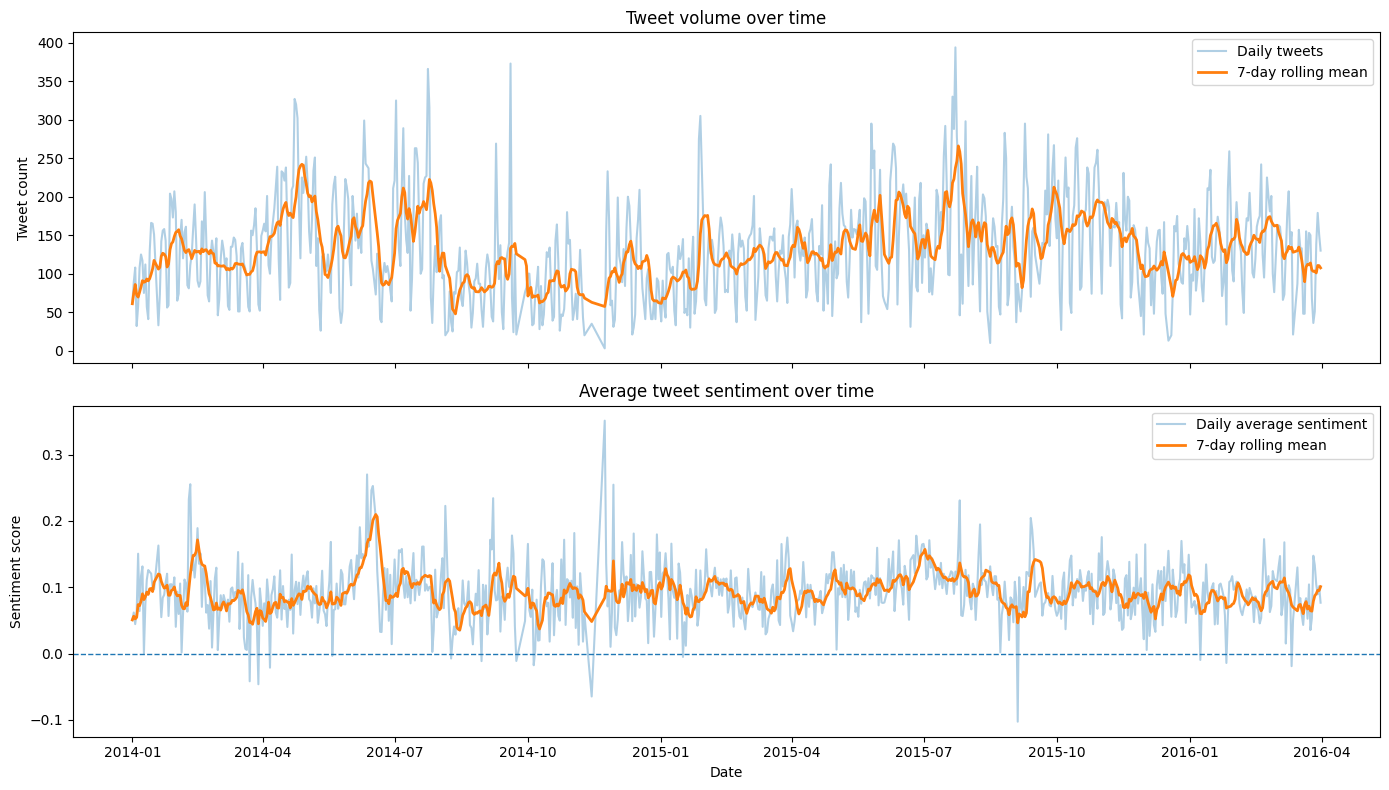

In [54]:

tweet_time = (
    tweets_df.groupby("date", as_index=False)
    .agg(tweet_count=("text", "size"), avg_sentiment=("sentiment_score", "mean"))
    .sort_values("date")
)

tweet_time["tweet_count_7d"] = tweet_time["tweet_count"].rolling(7, min_periods=1).mean()
tweet_time["avg_sentiment_7d"] = tweet_time["avg_sentiment"].rolling(7, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(tweet_time["date"], tweet_time["tweet_count"], alpha=0.35, label="Daily tweets")
axes[0].plot(tweet_time["date"], tweet_time["tweet_count_7d"], linewidth=2, label="7-day rolling mean")
axes[0].set_title('Tweet volume over time')
axes[0].set_ylabel('Tweet count')
axes[0].legend()

axes[1].plot(tweet_time["date"], tweet_time["avg_sentiment"], alpha=0.35, label="Daily average sentiment")
axes[1].plot(tweet_time["date"], tweet_time["avg_sentiment_7d"], linewidth=2, label="7-day rolling mean")
axes[1].axhline(0, linestyle='--', linewidth=1)
axes[1].set_title('Average tweet sentiment over time')
axes[1].set_ylabel('Sentiment score')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

SENTIMENT ANALYSIS USING VADER

In [20]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon")

# Initialise VADER
sia = SentimentIntensityAnalyzer()

# Function to compute compound sentiment
def vader_compound(text: str) -> float:
    text = "" if text is None else str(text)
    return float(sia.polarity_scores(text)["compound"])

# Apply to dataframe
tweets_df["sentiment_score"] = tweets_df["clean_text"].apply(vader_compound)

display(tweets_df[["clean_text", "sentiment_score"]].head(10))

,clean_text,sentiment_score
0,summary yesterdays webcast featuring traderedu...,0.0000
1,itv boost apple apple,0.4019
2,iphone users intelligent samsung blackberry ht...,0.4588
3,wrapup trading set review apple,0.0000
4,apple screwed big time,-0.4939
5,wall kicks new year lower note stock stocks st...,-0.2960
6,heres apple making huge push healthcare,0.3182
7,trade ideas futures wins bank,0.5719
8,having breathing difficulties,-0.2960
9,emylers cheekys board date company activities ...,0.0000


# MERGE BOTH THE DATAFRAMES IN A PARQUET FILE FORM 

In [21]:
# Keep required technical columns
tech_cols = [
    "ticker", "date", "target",
    "open", "high", "low", "close", "volume", "return",
    "ma5", "ma10", "volatility_5", "momentum_5", "volume_change", "lag1", "lag2"
]
price_df = price_df[tech_cols].copy()

# Build daily tweet features (one row per ticker-date)
tweet_daily = (
    tweets_df.groupby(["ticker", "date"], as_index=False)
    .agg(
        sentiment_score=("sentiment_score", "mean"),
        sentiment_std=("sentiment_score", "std"),
        tweet_count=("text", "count"),
        engagement=("engagement", "sum"),
        retweet_count=("retweet_count", "sum"),
        favorite_count=("favorite_count", "sum"),
        word_count=("word_count", "mean"),
        lexical_diversity=("lexical_diversity", "mean"),
        has_question=("has_question", "mean"),
        has_exclaim=("has_exclaim", "mean")
    )
)

# Define tweet_cols BEFORE using it
tweet_cols = [
    "sentiment_score", "sentiment_std", "tweet_count", "engagement",
    "retweet_count", "favorite_count", "word_count",
    "lexical_diversity", "has_question", "has_exclaim"
]

# Merge
merged_df = price_df.merge(tweet_daily, on=["ticker", "date"], how="left")
merged_df = merged_df.sort_values(["ticker", "date"]).reset_index(drop=True)

for col in tweet_cols:
    merged_df[col] = merged_df.groupby("ticker")[col].shift(1)

merged_df[tweet_cols] = merged_df[tweet_cols].fillna(0)

# Save parquet
output_file = "merged_stock_tweet_data.parquet"

merged_df["ticker"] = merged_df["ticker"].astype("object")
merged_df["date"] = pd.to_datetime(merged_df["date"]).dt.normalize()
merged_df = merged_df.sort_values(["date", "ticker"]).reset_index(drop=True)
merged_df.to_parquet(output_file, index=False, engine="fastparquet")

# Quick verification
check_df = pd.read_parquet(output_file, engine="fastparquet")
print("Merged shape:", merged_df.shape)
display(merged_df.head())


Merged shape: (90102, 26)


,ticker,date,target,open,high,low,close,volume,return,ma5,...,sentiment_score,sentiment_std,tweet_count,engagement,retweet_count,favorite_count,word_count,lexical_diversity,has_question,has_exclaim
0,AAPL,2012-09-04,0,95.108574,96.448570,94.928574,96.424286,91973000.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ABB,2012-09-04,1,17.340000,17.370001,17.139999,17.240000,1474300.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AEP,2012-09-04,0,43.000000,43.250000,42.830002,43.139999,2068800.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AMGN,2012-09-04,0,83.800003,84.599998,83.370003,84.330002,3719200.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AMZN,2012-09-04,0,248.270004,251.000000,244.660004,247.880005,3950800.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# LOAD THE MERGED PARQUET DATA AND SORT THE DATA 

In [22]:
# Use fastparquet explicitly (avoids pyarrow extension errors you were getting)
df = pd.read_parquet("merged_stock_tweet_data.parquet", engine="fastparquet")

# Recreate engineered features 
df["hl_pct"] = (df["high"] - df["low"]) / df["close"]
df["oc_pct"] = (df["close"] - df["open"]) / df["open"]
df["ma5_ratio"] = df["close"] / df["ma5"]
df["ma10_ratio"] = df["close"] / df["ma10"]
df["lag1_return"] = df.groupby("ticker")["return"].shift(1)
df["lag2_return"] = df.groupby("ticker")["return"].shift(2)

print("Final shape:", df.shape)
display(df.head())


Final shape: (90102, 32)


,ticker,date,target,open,high,low,close,volume,return,ma5,...,word_count,lexical_diversity,has_question,has_exclaim,hl_pct,oc_pct,ma5_ratio,ma10_ratio,lag1_return,lag2_return
0,AAPL,2012-09-04,0,95.108574,96.448570,94.928574,96.424286,91973000.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.015764,0.013834,NaN,NaN,NaN,NaN
1,ABB,2012-09-04,1,17.340000,17.370001,17.139999,17.240000,1474300.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.013341,-0.005767,NaN,NaN,NaN,NaN
2,AEP,2012-09-04,0,43.000000,43.250000,42.830002,43.139999,2068800.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.009736,0.003256,NaN,NaN,NaN,NaN
3,AMGN,2012-09-04,0,83.800003,84.599998,83.370003,84.330002,3719200.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.014585,0.006325,NaN,NaN,NaN,NaN
4,AMZN,2012-09-04,0,248.270004,251.000000,244.660004,247.880005,3950800.0,NaN,NaN,...,0.0,0.0,0.0,0.0,0.025577,-0.001571,NaN,NaN,NaN,NaN


# SPLIT THE MERGED DATA INTO TRAIN - VALIDATION - TEST DATA

In [23]:
def split_by_unique_dates(df: pd.DataFrame, train_ratio=0.70, val_ratio=0.15):
    temp = df.copy()
    temp["date"] = pd.to_datetime(temp["date"], errors="coerce")
    temp = temp.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    unique_dates = np.array(sorted(temp["date"].unique()))
    n_dates = len(unique_dates)

    train_end = int(n_dates * train_ratio)
    val_end = int(n_dates * (train_ratio + val_ratio))

    train_dates = unique_dates[:train_end]
    val_dates = unique_dates[train_end:val_end]
    test_dates = unique_dates[val_end:]

    train_df = temp[temp["date"].isin(train_dates)].copy()
    val_df = temp[temp["date"].isin(val_dates)].copy()
    test_df = temp[temp["date"].isin(test_dates)].copy()

    return train_df, val_df, test_df

train_df, val_df, test_df = split_by_unique_dates(df)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

Train: (63325, 32)
Val:   (13700, 32)
Test:  (13077, 32)


# DEFINE FEATURE SETS 

In [24]:
price_features = [
    "return", "lag1_return", "lag2_return",
    "volatility_5", "momentum_5", "volume_change",
    "hl_pct", "oc_pct", "ma5_ratio", "ma10_ratio"
]

tweet_features = [
    "sentiment_score", "engagement", "retweet_count",
    "favorite_count", "word_count", "lexical_diversity",
    "has_question", "has_exclaim"
]

price_features = [c for c in price_features if c in df.columns]
tweet_features = [c for c in tweet_features if c in df.columns]

price_only = price_features
price_plus_tweets = price_features + tweet_features

print("Price only features:", price_only)
print("Price + tweets features:", price_plus_tweets)

Price only features: ['return', 'lag1_return', 'lag2_return', 'volatility_5', 'momentum_5', 'volume_change', 'hl_pct', 'oc_pct', 'ma5_ratio', 'ma10_ratio']
Price + tweets features: ['return', 'lag1_return', 'lag2_return', 'volatility_5', 'momentum_5', 'volume_change', 'hl_pct', 'oc_pct', 'ma5_ratio', 'ma10_ratio', 'sentiment_score', 'engagement', 'retweet_count', 'favorite_count', 'word_count', 'lexical_diversity', 'has_question', 'has_exclaim']


# LSTM SEQUENCE CREATION 

In [25]:
def create_lstm_sequences(
    data: pd.DataFrame,
    feature_cols: list,
    target_col: str = "target",
    window_size: int = 30,
    ticker_col: str = "ticker",
    date_col: str = "date",
):
    X_sequences = []
    y_sequences = []

    for _, ticker_df in data.groupby(ticker_col):
        ticker_df = ticker_df.sort_values(date_col).reset_index(drop=True)

        if len(ticker_df) <= window_size:
            continue

        X_vals = ticker_df[feature_cols].to_numpy(dtype=np.float32)
        y_vals = ticker_df[target_col].to_numpy(dtype=np.float32)

        for i in range(window_size, len(ticker_df)):
            X_sequences.append(X_vals[i - window_size:i])
            y_sequences.append(y_vals[i])

    X = np.array(X_sequences, dtype=np.float32)
    y = np.array(y_sequences, dtype=np.float32)
    return X, y



In [26]:
def prepare_sequences(train_df, val_df, test_df, features, window_size=30):
    tr = train_df.copy()
    va = val_df.copy()
    te = test_df.copy()

    tr = tr.dropna(subset=["target"]).copy()
    va = va.dropna(subset=["target"]).copy()
    te = te.dropna(subset=["target"]).copy()

    for d in [tr, va, te]:
        d[features] = d[features].replace([np.inf, -np.inf], np.nan)

    train_medians = tr[features].median()

    tr[features] = tr[features].fillna(train_medians)
    va[features] = va[features].fillna(train_medians)
    te[features] = te[features].fillna(train_medians)

    scaler = StandardScaler()
    tr[features] = scaler.fit_transform(tr[features])
    va[features] = scaler.transform(va[features])
    te[features] = scaler.transform(te[features])

    Xtr, ytr = create_lstm_sequences(tr, features, target_col="target", window_size=window_size)
    Xva, yva = create_lstm_sequences(va, features, target_col="target", window_size=window_size)
    Xte, yte = create_lstm_sequences(te, features, target_col="target", window_size=window_size)

    print("Train target mean:", ytr.mean())
    print("Val target mean:",   yva.mean())
    print("Test target mean:",  yte.mean())

    return Xtr, ytr, Xva, yva, Xte, yte, scaler

# LSTM MODEL

In [27]:
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization

def build_lstm(n_timesteps, n_features):
    model = Sequential([
        Input(shape=(n_timesteps, n_features)),
        LSTM(128, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

model = build_lstm(n_timesteps=30, n_features=len(price_only))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,457 (482.25 KB)

 Trainable params: 123,073 (480.75 KB)

 Non-trainable params: 384 (1.50 KB)

# BILSTM MODEL 

In [28]:
def build_bilstm(n_timesteps, n_features):
    model = Sequential([
        Input(shape=(n_timesteps, n_features)),
        Bidirectional(LSTM(128, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.3),
        Bidirectional(LSTM(64)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

model = build_bilstm(n_timesteps=30, n_features=len(price_only))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312,385 (1.19 MB)

 Trainable params: 311,617 (1.19 MB)

 Non-trainable params: 768 (3.00 KB)

TRAINING CALLBACKS 

In [29]:
def get_callbacks():
    return [
        EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6),
    ]


In [30]:

def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_prob = np.asarray(y_prob).ravel()
    y_pred = (y_prob > threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "Confusion_Matrix": confusion_matrix(y_true, y_pred),
        "Classification_Report": classification_report(y_true, y_pred, zero_division=0),
    }

# COMPARE MODELS WITH VS WITHOUT TWEET FEATURES 

In [31]:
from sklearn.utils.class_weight import compute_class_weight

WINDOW_SIZE = 30

def run_sequence_experiment(model_type: str, features: list, window_size: int = WINDOW_SIZE):
    Xtr, ytr, Xva, yva, Xte, yte, scaler = prepare_sequences(
        train_df, val_df, test_df, features, window_size=window_size
    )

    n_timesteps = Xtr.shape[1]
    n_features = Xtr.shape[2]

    if model_type == "LSTM":
        model = build_lstm(n_timesteps, n_features)
    elif model_type == "BiLSTM":
        model = build_bilstm(n_timesteps, n_features)
    else:
        raise ValueError("model_type must be 'LSTM', 'BiLSTM'")

    classes     = np.unique(ytr)
    weights     = compute_class_weight("balanced", classes=classes, y=ytr)
    class_weight_dict = dict(zip(classes.astype(int), weights))

    model.fit(
        Xtr, ytr,
        validation_data=(Xva, yva),
        epochs=30,
        batch_size=128,
        callbacks=get_callbacks(),
        class_weight=class_weight_dict,
        verbose=1,
    )
    train_eval = model.evaluate(Xtr, ytr, verbose=0, return_dict=True)
    val_eval = model.evaluate(Xva, yva, verbose=0, return_dict=True)
    test_eval = model.evaluate(Xte, yte, verbose=0, return_dict=True)

    y_prob = model.predict(Xte, verbose=0).ravel()
    pred_metrics = evaluate_predictions(yte, y_prob)

    result = {
        "Model": model_type,
        "Features": "Price only" if features == price_only else "Price + Tweets",
        "Train Loss": train_eval["loss"],
        "Train Acc": train_eval["accuracy"],
        "Train AUC": train_eval["auc"],
        "Val Loss": val_eval["loss"],
        "Val Acc": val_eval["accuracy"],
        "Val AUC": val_eval["auc"],
        "Test Loss": test_eval["loss"],
        "Test Acc": test_eval["accuracy"],
        "Test AUC": test_eval["auc"],
        "Test Precision": pred_metrics["Precision"],
        "Test Recall": pred_metrics["Recall"],
        "Test F1": pred_metrics["F1"],
        "Test ROC_AUC": pred_metrics["ROC_AUC"],
    }

    print(f"\n{model_type} | {'Price only' if features == price_only else 'Price + Tweets'}")
    print(pred_metrics["Classification_Report"])
    print("Confusion matrix:\n", pred_metrics["Confusion_Matrix"])

    return result

# RANDOM FOREST MODEL

In [36]:
from sklearn.ensemble import RandomForestClassifier

def run_rf_experiment(features: list, window_size: int = WINDOW_SIZE):
    Xtr, ytr, Xva, yva, Xte, yte, scaler = prepare_sequences(
        train_df, val_df, test_df, features, window_size=window_size
    )

    # Random Forest gets last timestep only
    Xtr_rf = Xtr[:, -1, :]
    Xva_rf = Xva[:, -1, :]
    Xte_rf = Xte[:, -1, :]

    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=50,
        min_samples_leaf=25,
        max_features="sqrt",
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )
    
    rf_model.fit(Xtr_rf, ytr)

    ytr_pred = rf_model.predict(Xtr_rf)
    yva_pred = rf_model.predict(Xva_rf)
    yte_pred = rf_model.predict(Xte_rf)

    ytr_prob = rf_model.predict_proba(Xtr_rf)[:, 1]
    yva_prob = rf_model.predict_proba(Xva_rf)[:, 1]
    yte_prob = rf_model.predict_proba(Xte_rf)[:, 1]

    result = {
        "Model": "Random Forest",
        "Features": "Price only" if features == price_only else "Price + Tweets",
        "Train Loss": np.nan,
        "Train Acc": accuracy_score(ytr, ytr_pred),
        "Train AUC": roc_auc_score(ytr, ytr_prob),
        "Val Loss": np.nan,
        "Val Acc": accuracy_score(yva, yva_pred),
        "Val AUC": roc_auc_score(yva, yva_prob),
        "Test Loss": np.nan,
        "Test Acc": accuracy_score(yte, yte_pred),
        "Test AUC": roc_auc_score(yte, yte_prob),
        "Test Precision": precision_score(yte, yte_pred, zero_division=0),
        "Test Recall": recall_score(yte, yte_pred, zero_division=0),
        "Test F1": f1_score(yte, yte_pred, zero_division=0),
        "Test ROC_AUC": roc_auc_score(yte, yte_prob),
    }

    print(f"\nRandom Forest | {'Price only' if features == price_only else 'Price + Tweets'}")
    print(classification_report(yte, yte_pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(yte, yte_pred))

    return result



# XGBOOST MODEL

In [60]:
from xgboost import XGBClassifier

def run_xgb_experiment(features: list, window_size: int = WINDOW_SIZE):
    Xtr, ytr, Xva, yva, Xte, yte, scaler = prepare_sequences(
        train_df, val_df, test_df, features, window_size=window_size
    )

    # XGBoost gets last timestep only (same as RF)
    Xtr_xgb = Xtr[:, -1, :]
    Xva_xgb = Xva[:, -1, :]
    Xte_xgb = Xte[:, -1, :]

    xgb_model = XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=SEED,
        eval_metric="logloss",
        n_jobs=-1
    )
    xgb_model.fit(Xtr_xgb, ytr)

    ytr_pred = xgb_model.predict(Xtr_xgb)
    yva_pred = xgb_model.predict(Xva_xgb)
    yte_pred = xgb_model.predict(Xte_xgb)

    ytr_prob = xgb_model.predict_proba(Xtr_xgb)[:, 1]
    yva_prob = xgb_model.predict_proba(Xva_xgb)[:, 1]
    yte_prob = xgb_model.predict_proba(Xte_xgb)[:, 1]

    result = {
        "Model": "XGBoost",
        "Features": "Price only" if features == price_only else "Price + Tweets",
        "Train Loss": np.nan,
        "Train Acc": accuracy_score(ytr, ytr_pred),
        "Train AUC": roc_auc_score(ytr, ytr_prob),
        "Val Loss": np.nan,
        "Val Acc": accuracy_score(yva, yva_pred),
        "Val AUC": roc_auc_score(yva, yva_prob),
        "Test Loss": np.nan,
        "Test Acc": accuracy_score(yte, yte_pred),
        "Test AUC": roc_auc_score(yte, yte_prob),
        "Test Precision": precision_score(yte, yte_pred, zero_division=0),
        "Test Recall": recall_score(yte, yte_pred, zero_division=0),
        "Test F1": f1_score(yte, yte_pred, zero_division=0),
        "Test ROC_AUC": roc_auc_score(yte, yte_prob),
    }

    print(f"\nXGBoost | {'Price only' if features == price_only else 'Price + Tweets'}")
    print(classification_report(yte, yte_pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(yte, yte_pred))

    return result

# DISPLAY RESULTS 

In [33]:
RESULTS_OUTPUT = "model_comparison_results.csv"

results = []

results.append(run_sequence_experiment("LSTM", price_only))

Train target mean: 0.5173186
Val target mean: 0.5209765
Test target mean: 0.54220563
Epoch 1/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 63s 123ms/step - accuracy: 0.5047 - auc: 0.5068 - loss: 0.7127 - val_accuracy: 0.4962 - val_auc: 0.4985 - val_loss: 0.6972 - learning_rate: 0.0010
Epoch 2/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 63s 133ms/step - accuracy: 0.5060 - auc: 0.5092 - loss: 0.6993 - val_accuracy: 0.5066 - val_auc: 0.4974 - val_loss: 0.6968 - learning_rate: 0.0010
Epoch 3/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 67s 141ms/step - accuracy: 0.5017 - auc: 0.5034 - loss: 0.6975 - val_accuracy: 0.5047 - val_auc: 0.4874 - val_loss: 0.6968 - learning_rate: 0.0010
Epoch 4/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 97s 204ms/step - accuracy: 0.5130 - auc: 0.5168 - loss: 0.6942 - val_accuracy: 0.5046 - val_auc: 0.5061 - val_loss: 0.6936 - learning_rate: 5.0000e-04
Epoch 5/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 89s 93ms/step - accuracy: 0.5111 - auc: 0.5180 - loss: 0.6939 - val_accuracy: 0.5068 - val_auc: 0.5038 - val_loss: 0.6933 -

In [34]:
results.append(run_sequence_experiment("LSTM", price_plus_tweets))

Train target mean: 0.5173186
Val target mean: 0.5209765
Test target mean: 0.54220563
Epoch 1/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 110s 212ms/step - accuracy: 0.5047 - auc: 0.5047 - loss: 0.7081 - val_accuracy: 0.4983 - val_auc: 0.4923 - val_loss: 0.6949 - learning_rate: 0.0010
Epoch 2/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 127s 266ms/step - accuracy: 0.5071 - auc: 0.5086 - loss: 0.6980 - val_accuracy: 0.5203 - val_auc: 0.5027 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 3/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 45s 94ms/step - accuracy: 0.5033 - auc: 0.5072 - loss: 0.6954 - val_accuracy: 0.4765 - val_auc: 0.4920 - val_loss: 0.6977 - learning_rate: 0.0010
Epoch 4/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 47s 99ms/step - accuracy: 0.5031 - auc: 0.5066 - loss: 0.6953 - val_accuracy: 0.5004 - val_auc: 0.5018 - val_loss: 0.6949 - learning_rate: 0.0010
Epoch 5/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 80s 94ms/step - accuracy: 0.5059 - auc: 0.5064 - loss: 0.6940 - val_accuracy: 0.5192 - val_auc: 0.5059 - val_loss: 0.6925 - lea

In [37]:
results.append(run_sequence_experiment("BiLSTM", price_only))

Train target mean: 0.5173186
Val target mean: 0.5209765
Test target mean: 0.54220563
Epoch 1/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 102s 188ms/step - accuracy: 0.5038 - auc: 0.5046 - loss: 0.7204 - val_accuracy: 0.4990 - val_auc: 0.5037 - val_loss: 0.6984 - learning_rate: 0.0010
Epoch 2/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 129s 161ms/step - accuracy: 0.5043 - auc: 0.5057 - loss: 0.6991 - val_accuracy: 0.5005 - val_auc: 0.5185 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 3/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 163s 344ms/step - accuracy: 0.5068 - auc: 0.5110 - loss: 0.6974 - val_accuracy: 0.5092 - val_auc: 0.4969 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 4/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - accuracy: 0.5036 - auc: 0.5061 - loss: 0.6963 - val_accuracy: 0.4971 - val_auc: 0.4970 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 5/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 50s 106ms/step - accuracy: 0.5098 - auc: 0.5149 - loss: 0.6939 - val_accuracy: 0.4964 - val_auc: 0.5009 - val_loss: 0.6955 -

In [38]:
results.append(run_sequence_experiment("BiLSTM", price_plus_tweets))

Train target mean: 0.5173186
Val target mean: 0.5209765
Test target mean: 0.54220563
Epoch 1/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 69s 130ms/step - accuracy: 0.5095 - auc: 0.5115 - loss: 0.7096 - val_accuracy: 0.5055 - val_auc: 0.4995 - val_loss: 0.6969 - learning_rate: 0.0010
Epoch 2/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 103s 217ms/step - accuracy: 0.5040 - auc: 0.5070 - loss: 0.6979 - val_accuracy: 0.5198 - val_auc: 0.5128 - val_loss: 0.6924 - learning_rate: 0.0010
Epoch 3/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - accuracy: 0.5062 - auc: 0.5084 - loss: 0.6962 - val_accuracy: 0.4895 - val_auc: 0.5045 - val_loss: 0.6954 - learning_rate: 0.0010
Epoch 4/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 49s 102ms/step - accuracy: 0.5054 - auc: 0.5082 - loss: 0.6952 - val_accuracy: 0.5228 - val_auc: 0.4958 - val_loss: 0.6948 - learning_rate: 0.0010
Epoch 5/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 73s 154ms/step - accuracy: 0.5076 - auc: 0.5128 - loss: 0.6946 - val_accuracy: 0.4973 - val_auc: 0.5044 - val_loss: 0.6952 - l

In [39]:
results.append(run_rf_experiment(price_only))

Train target mean: 0.5173186
Val target mean: 0.5209765
Test target mean: 0.54220563

Random Forest | Price only
              precision    recall  f1-score   support

         0.0       0.46      0.60      0.52      4778
         1.0       0.54      0.40      0.46      5659

    accuracy                           0.49     10437
   macro avg       0.50      0.50      0.49     10437
weighted avg       0.50      0.49      0.48     10437

Confusion matrix:
 [[2863 1915]
 [3423 2236]]


In [40]:
results.append(run_rf_experiment(price_plus_tweets))

Train target mean: 0.5173186
Val target mean: 0.5209765
Test target mean: 0.54220563

Random Forest | Price + Tweets
              precision    recall  f1-score   support

         0.0       0.45      0.57      0.50      4778
         1.0       0.54      0.42      0.47      5659

    accuracy                           0.49     10437
   macro avg       0.50      0.50      0.49     10437
weighted avg       0.50      0.49      0.49     10437

Confusion matrix:
 [[2709 2069]
 [3264 2395]]


In [61]:
results.append(run_xgb_experiment(price_only))

Train target mean: 0.5173186
Val target mean: 0.5209765
Test target mean: 0.54220563

XGBoost | Price only
              precision    recall  f1-score   support

         0.0       0.46      0.26      0.33      4778
         1.0       0.54      0.74      0.63      5659

    accuracy                           0.52     10437
   macro avg       0.50      0.50      0.48     10437
weighted avg       0.50      0.52      0.49     10437

Confusion matrix:
 [[1221 3557]
 [1448 4211]]


In [42]:
results.append(run_xgb_experiment(price_plus_tweets))

Train target mean: 0.5173186
Val target mean: 0.5209765
Test target mean: 0.54220563

XGBoost | Price + Tweets
              precision    recall  f1-score   support

         0.0       0.46      0.21      0.29      4778
         1.0       0.54      0.79      0.64      5659

    accuracy                           0.53     10437
   macro avg       0.50      0.50      0.47     10437
weighted avg       0.50      0.53      0.48     10437

Confusion matrix:
 [[1007 3771]
 [1183 4476]]


In [43]:
results_df = pd.DataFrame(results)

display_cols = [
    "Model", "Features",
    "Train Acc", "Train AUC",
    "Val Acc", "Val AUC",
    "Test Acc", "Test AUC",
    "Test Precision", "Test Recall", "Test F1", "Test ROC_AUC",
]

results_df = results_df[display_cols].sort_values(["Model", "Features"]).reset_index(drop=True)
results_df.to_csv(RESULTS_OUTPUT, index=False)

display(results_df)
print(f"Saved comparison table to: {RESULTS_OUTPUT}")

,Model,Features,Train Acc,Train AUC,Val Acc,Val AUC,Test Acc,Test AUC,Test Precision,Test Recall,Test F1,Test ROC_AUC
0,BiLSTM,Price + Tweets,0.520926,0.524561,0.519801,0.512753,0.531954,0.502811,0.542612,0.870825,0.668611,0.502079
1,BiLSTM,Price only,0.507749,0.518974,0.500543,0.518536,0.477340,0.500151,0.543814,0.223714,0.317015,0.500120
2,LSTM,Price + Tweets,0.511290,0.514405,0.510850,0.509208,0.483760,0.500474,0.537733,0.341226,0.417514,0.499447
3,LSTM,Price only,0.527399,0.535054,0.504611,0.506065,0.518061,0.510943,0.547187,0.644460,0.591853,0.510607
4,Random Forest,Price + Tweets,0.540328,0.566280,0.493038,0.493109,0.489029,0.492260,0.536514,0.423220,0.473180,0.492260
5,Random Forest,Price only,0.539438,0.563617,0.491320,0.490861,0.488550,0.492384,0.538665,0.395123,0.455861,0.492384
6,XGBoost,Price + Tweets,0.564605,0.601526,0.500814,0.489711,0.525343,0.500326,0.542743,0.790952,0.643751,0.500326
7,XGBoost,Price only,0.563090,0.597903,0.505335,0.494124,0.520456,0.496688,0.542096,0.744124,0.627244,0.496688


Saved comparison table to: model_comparison_results.csv


FEATURE CORRELATION HEATMAP 

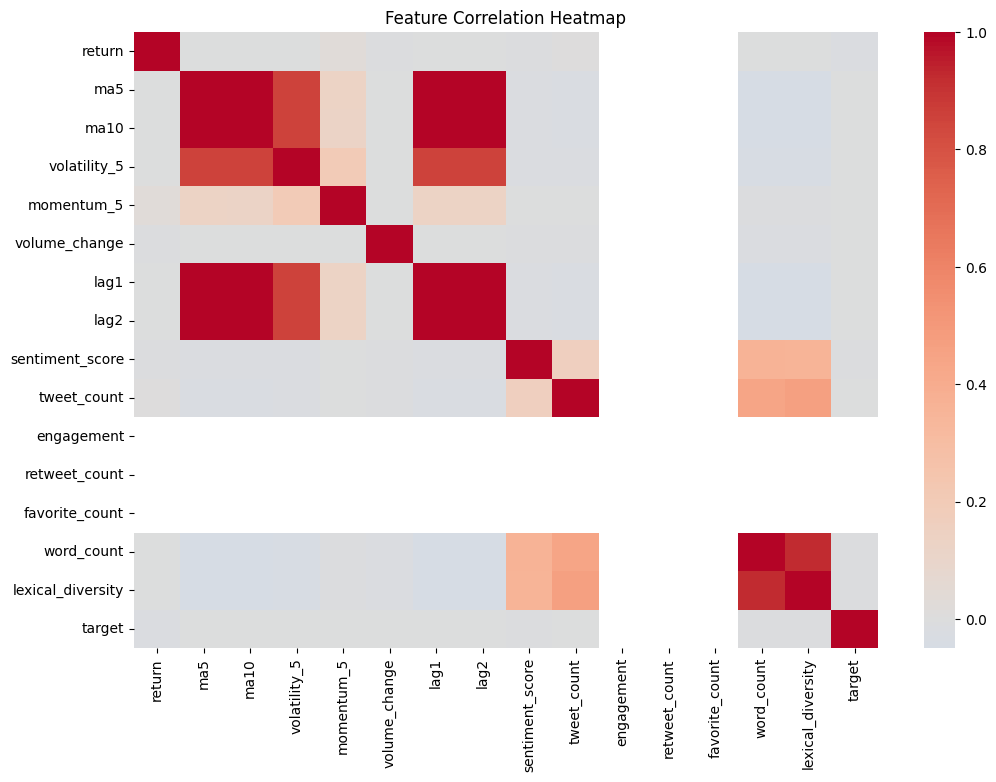

In [65]:
candidate_cols = [
    "return", "ma5", "ma10", "volatility_5", "momentum_5",
    "volume_change", "lag1", "lag2",
    "sentiment_score", "tweet_count", "engagement",
    "retweet_count", "favorite_count", "word_count",
    "lexical_diversity", "target"
]

feature_cols_for_corr = [c for c in candidate_cols if c in df.columns]
corr = df[feature_cols_for_corr].corr()

if sns is not None:
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Feature Correlation Heatmap")
    plt.show()
else:
    plt.figure(figsize=(12, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Feature Correlation Heatmap")
    plt.show()

Bar chart comparing test AUC, Accuracy and F1 Scores across all models 

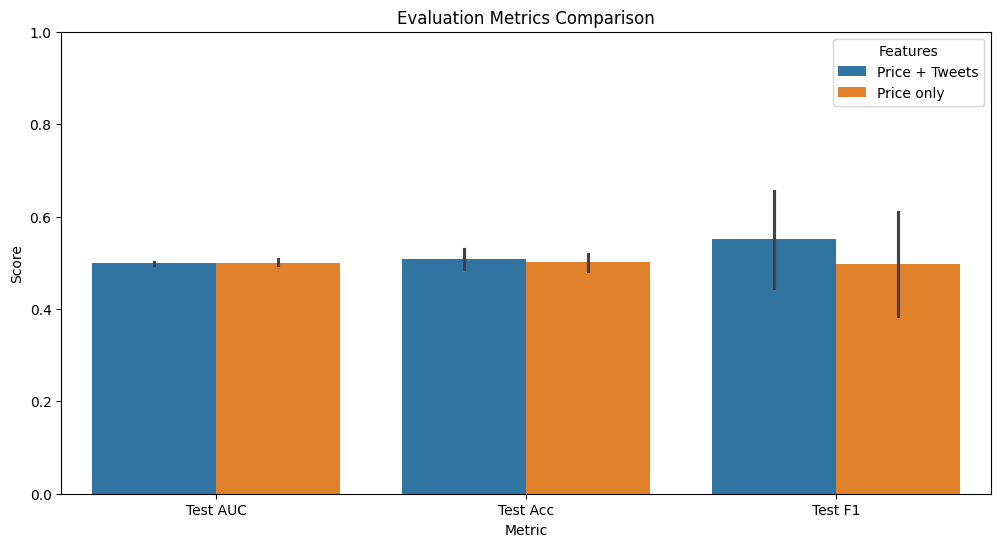

In [73]:
metrics_to_plot = [c for c in ["Test AUC", "Test Acc", "Test F1"] if c in results_df.columns]

if len(metrics_to_plot) > 0:
    plot_df = results_df.melt(
        id_vars=["Model", "Features"] if "Features" in results_df.columns else ["Model"],
        value_vars=metrics_to_plot,
        var_name="Metric",
        value_name="Score"
    )

    if sns is not None:
        plt.figure(figsize=(12, 6))
        hue_col = "Features" if "Features" in plot_df.columns else "Model"
        sns.barplot(data=plot_df, x="Metric", y="Score", hue=hue_col)
        plt.title("Evaluation Metrics Comparison")
        plt.ylim(0, 1)
        plt.show()

Grouped Bar chart compares Train, validation, and Test AUC for each model

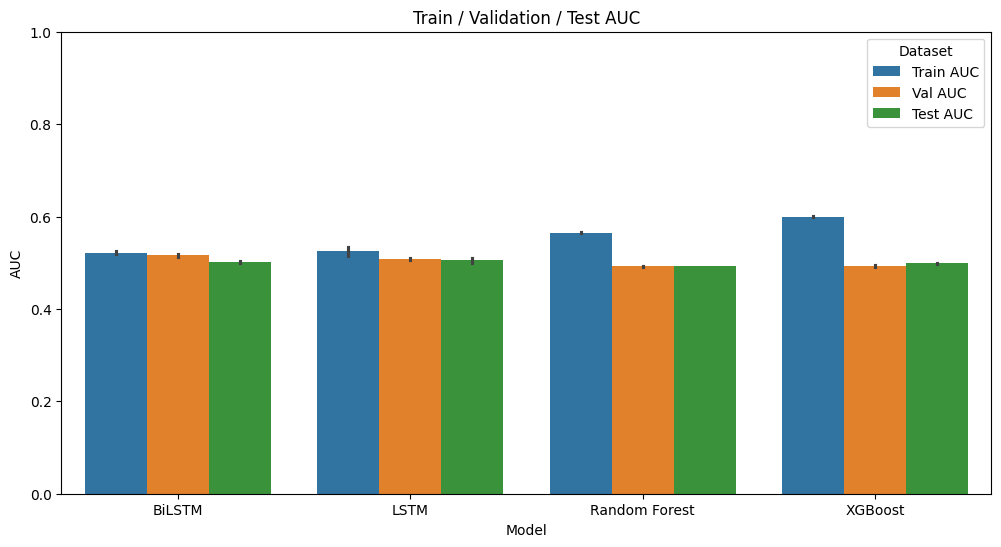

In [70]:
auc_cols = [c for c in ["Train AUC", "Val AUC", "Test AUC"] if c in results_df.columns]

if len(auc_cols) > 0:
    auc_df = results_df.melt(
        id_vars=["Model", "Features"] if "Features" in results_df.columns else ["Model"],
        value_vars=auc_cols,
        var_name="Dataset",
        value_name="AUC"
    )

    if sns is not None:
        plt.figure(figsize=(12, 6))
        sns.barplot(data=auc_df, x="Model", y="AUC", hue="Dataset")
        plt.title("Train / Validation / Test AUC")
        plt.ylim(0, 1)
        plt.show()